<a href="https://colab.research.google.com/github/pawanpal481/computer-vision-lab-file/blob/main/image_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

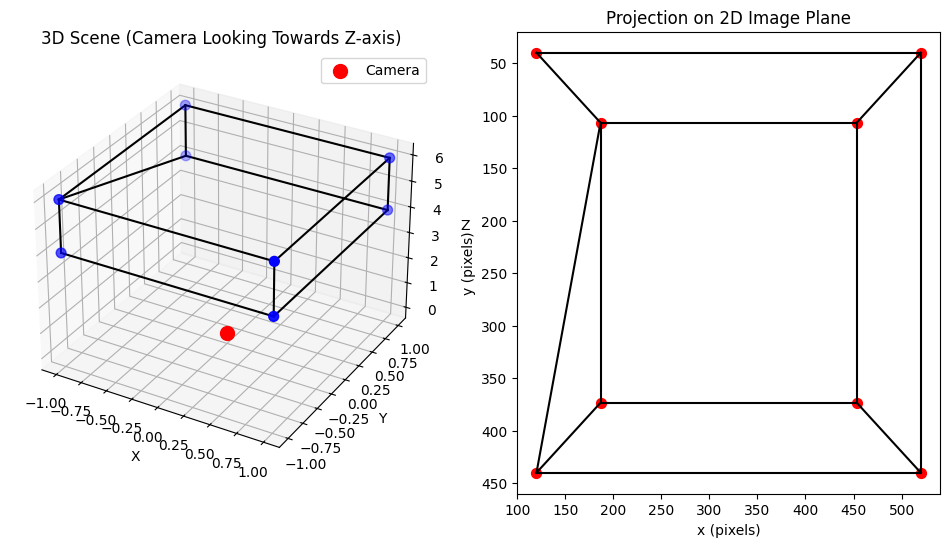

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Define camera intrinsic parameters
fx, fy = 800, 800
cx, cy = 320, 240
K = np.array([[fx, 0, cx],
              [0, fy, cy],
              [0,  0,  1]])

# 2. Define camera extrinsics
R = np.eye(3)
t = np.array([[0, 0, 0]]).T

# 3. Define 3D Points (cube)
cube_points = np.array([
    [-1, -1, 4], [1, -1, 4], [1, 1, 4], [-1, 1, 4],  # front face
    [-1, -1, 6], [1, -1, 6], [1, 1, 6], [-1, 1, 6]   # back face
])

# 4. Project 3D -> 2D
proj_points = (K @ (R @ cube_points.T + t)).T
proj_points = proj_points[:, :2] / proj_points[:, 2:3]

# 5. Visualization
fig = plt.figure(figsize=(12, 6))

# (a) 3D Scene View
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(cube_points[:, 0], cube_points[:, 1], cube_points[:, 2], c='blue', s=50)
ax1.set_title("3D Scene (Camera Looking Towards Z-axis)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

edges = [(0,1),(1,2),(2,3),(3,4),
         (4,5),(5,6),(6,7),(7,4),
         (0,4),(1,5),(2,6),(3,7)]

for e in edges:
    ax1.plot(*zip(cube_points[e[0]], cube_points[e[1]]), color='black')

ax1.scatter(0, 0, 0, c='red', s=100, label='Camera')
ax1.legend()

# (b) 2D Image Projection
ax2 = fig.add_subplot(122)
ax2.scatter(proj_points[:, 0], proj_points[:, 1], c='red', s=50)

for e in edges:
    ax2.plot(proj_points[[e[0], e[1]], 0],
             proj_points[[e[0], e[1]], 1],
             color='black')

ax2.set_title("Projection on 2D Image Plane")
ax2.invert_yaxis()
ax2.set_xlabel("x (pixels)")
ax2.set_ylabel("y (pixels)")

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

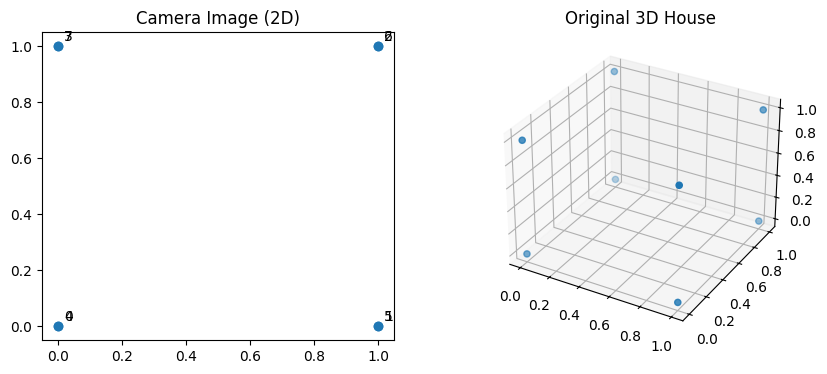

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 3 house points
pts = np.array([
    [0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0],
    [0, 0, 1], [1, 0, 1], [1, 1, 1], [0, 1, 1]
])

# Simple camera projection (camera 1)
p = np.array([[1, 0, 0], [0, 1, 0]])
img = pts @ p.T  # 2d projection

# Plot
fig = plt.figure(figsize=(10, 4))

# 2D image subplot
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(img[:, 0], img[:, 1])
ax1.set_title("Camera Image (2D)")
for i, p_val in enumerate(img):
    ax1.text(p_val[0] + 0.02, p_val[1] + 0.02, str(i))

# 3D house subplot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(pts[:, 0], pts[:, 1], pts[:, 2])
ax2.set_title("Original 3D House")

plt.show()

In [ ]:
import os
import cv2
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# STEP 2: Create Dataset Floder
#This folder will store all automatically
os.makedirs("image_dataset",exist_ok=True)
#STEP 3:Automatically   Downloaded image

#Download 5 random image from the interent for the dataset
#These random image act as a simple sample dataset.
image_urls=["https://unsplash.com/s/photos/nature",
            "https://unsplash.com/photos/orange-flowers-IicyiaPYGGI",
            ""

]

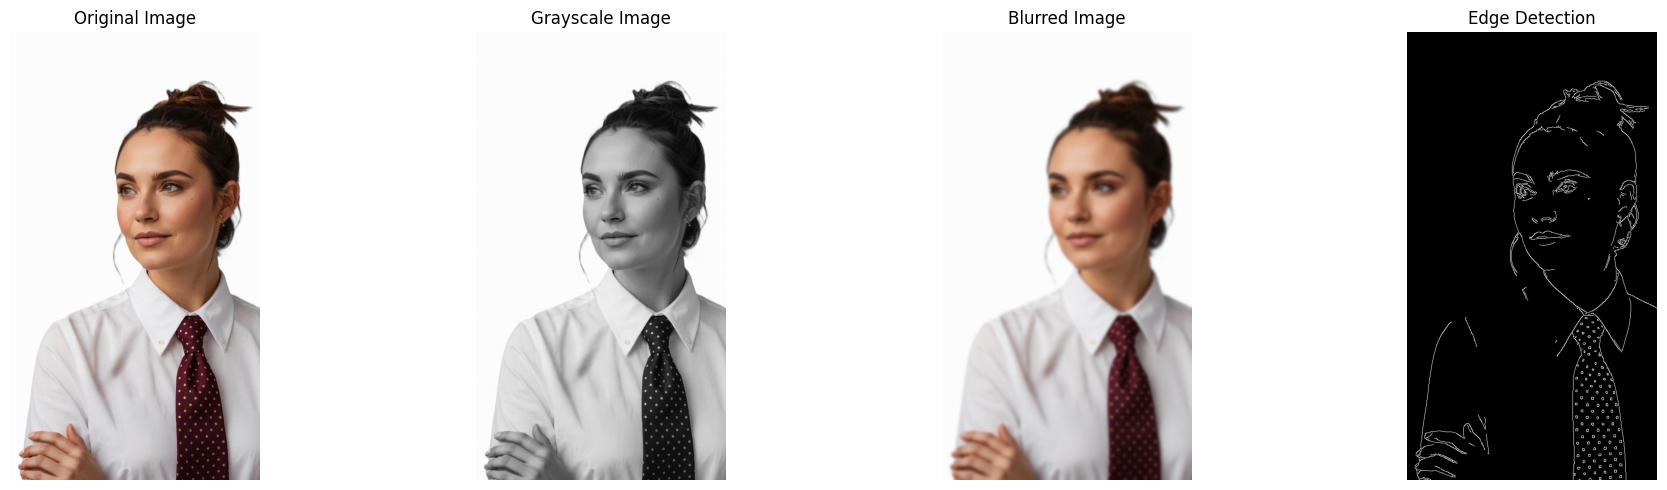

In [ ]:
import cv2
import matplotlib.pyplot as plt

#1. Image Acquisition: Load the image
# Corrected file path by removing the extra dot
image = cv2.imread("/content/Leonardo_Phoenix_Portraitstyle_image_featuring_a_woman_with_a_2.jpg")

# Check if the image was loaded successfully
if image is None:
    print("Error: Could not load the image.") # Indentation fixed
else:
    #OpenCV loads images in BGR format, so we convert it to RGB for plotting
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Initialize figure to hold all subplots
    plt.figure(figsize=(20, 5)) # Increased figure size to accommodate more subplots

    # Display the original image
    plt.subplot(1, 4, 1) # Changed to 1 row, 4 columns, 1st plot
    plt.imshow(image_rgb)
    plt.title('Original Image')
    plt.axis('off')

    # 2. Image Enhancement: Convert to grayscale for some operations
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    plt.subplot(1, 4, 2) # Changed to 1 row, 4 columns, 2nd plot
    plt.imshow(gray_image, cmap='gray')
    plt.title('Grayscale Image')
    plt.axis('off')

    # 3. Filtering: Apply a Gaussian Blur to smooth the image
    # Fixed variable name, function call syntax, and arguments
    blurred_image = cv2.GaussianBlur(image_rgb, (15, 15), 0) # Added sigmaX=0

    # Display the blurred image
    plt.subplot(1, 4, 3) # Changed to 1 row, 4 columns, 3rd plot
    plt.imshow(blurred_image)
    plt.title('Blurred Image')
    plt.axis('off') # Fixed typo 'of' to 'off'

    # Segmentation: Apply Canny Edge Detection
    edges = cv2.Canny(gray_image, 100, 200)

    # Display the detected edges
    plt.subplot(1, 4, 4) # Changed to 1 row, 4 columns, 4th plot
    plt.imshow(edges, cmap='gray')
    plt.title('Edge Detection')
    plt.axis('off')

    plt.tight_layout()
    plt.show() # Moved plt.show() to the end to display all plots at once

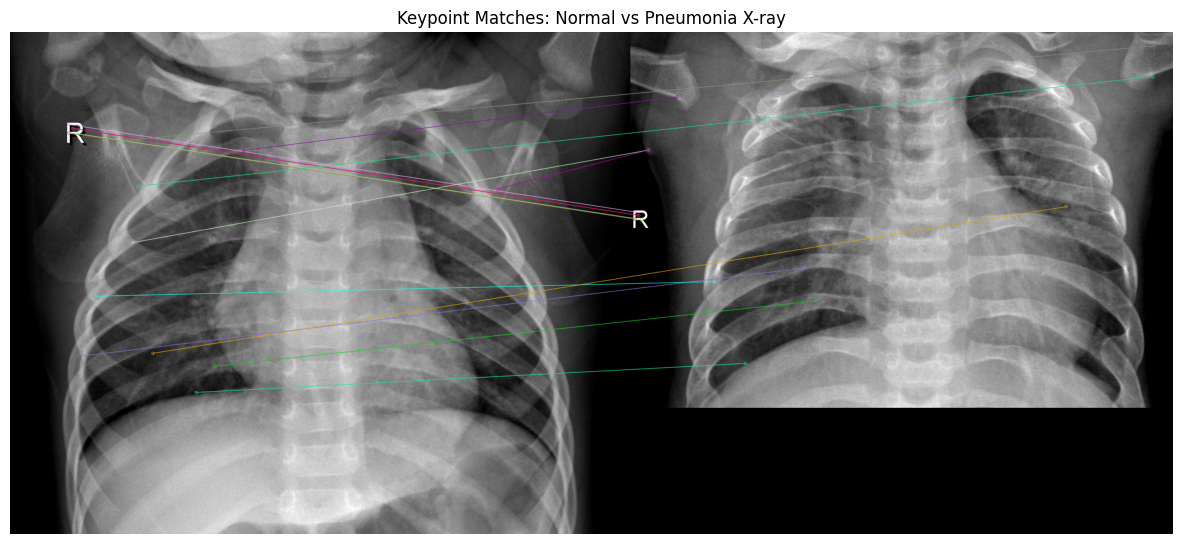

In [ ]:
import cv2
import matplotlib.pyplot as plt
normal_path = ("/content/normal.jpg")
pneumonia_path = ("/content/person1001_bacteria_2932.jpeg")
img1 = cv2.imread(normal_path, cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(pneumonia_path, cv2.IMREAD_GRAYSCALE)
# Check if images loaded
if img1 is None or img2 is None:
    print("Error loading images! One or both images could not be found or loaded.")
    # It's better to return in a notebook than exit()
    # You might want to raise an exception for more robust error handling
    exit()
#Create SIFT detector
sift = cv2.SIFT_create()
# Detect keypoints & descriptors
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)
# Match features using BFMatcher
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)
# Apply Lowe's ratio test
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)
# Draw matches
matched_img = cv2.drawMatches(
    img1, kp1, img2, kp2, good_matches[:30], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(15, 7))
plt.title("Keypoint Matches: Normal vs Pneumonia X-ray")
plt.imshow(matched_img, cmap="gray")
plt.axis("off")
plt.show()

Homography Matrix:
 [[ 3.06728184e+00 -2.71609059e+01  8.41050036e+02]
 [ 3.55741040e+00 -4.04743088e+01  1.76333220e+03]
 [ 3.09495968e-03 -2.97590255e-02  1.00000000e+00]]


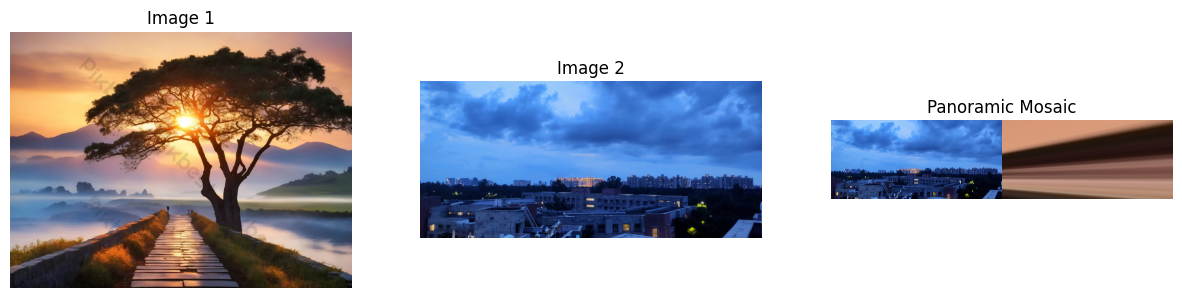

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Load two overlapping images
img1 = cv2.imread( "/content/ooo.jpg")
img2 = cv2.imread("/content/IMG20240816191203[1].jpg")
# Convert to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
# Detect keypoints and descriptors (using ORB)
orb = cv2.ORB_create (2000)
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)
# Match features using BFMatcher
matcher = cv2.BFMatcher (cv2.NORM_HAMMING, crossCheck=True)
matches = matcher.match(des1, des2)
# Sort matches by quality
matches = sorted(matches, key=lambda x: x.distance)
# Use top 50 matches
good_matches = matches[:50]
# Extract matched keypoints
src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1,1,2)
# Compute Homography
H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC)
print("Homography Matrix:\n", H)
# Warp image 1 into image 2 space
height, width = img2.shape[:2]
# Warp left image onto right image space
warped_img1 = cv2.warpPerspective(img1, H, (width*2, height))
# Create the panoramic mosaic
panorama = warped_img1.copy()
panorama[0:height, 0:width] = img2
# Display results
plt.figure(figsize=(15,8))
plt.subplot(1,3,1)
plt.title("Image 1")
plt.imshow(cv2.cvtColor(img1,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.subplot(1,3,2)
plt.title("Image 2")
plt.imshow(cv2.cvtColor(img2,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.subplot(1,3,3)
plt.title("Panoramic Mosaic")
plt.imshow(cv2.cvtColor(panorama,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Downloading: https://picsum.photos/300/300?random=1
Downloading: https://picsum.photos/300/300?random=2
Downloading: https://picsum.photos/300/300?random=3
Downloading: https://picsum.photos/300/300?random=4
Downloading: https://picsum.photos/300/300?random=5
Downloading: https://picsum.photos/300/300?random=6
Downloading: https://picsum.photos/300/300?random=7
Downloading: https://picsum.photos/300/300?random=8
Downloading: https://picsum.photos/300/300?random=9
Downloading: https://picsum.photos/300/300?random=10
Downloading: https://picsum.photos/300/300?random=11

 Clustering Complete!

===== Cluster 0 =====


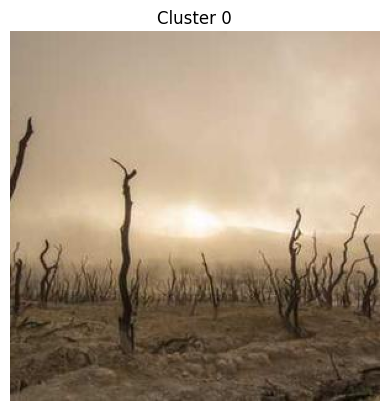

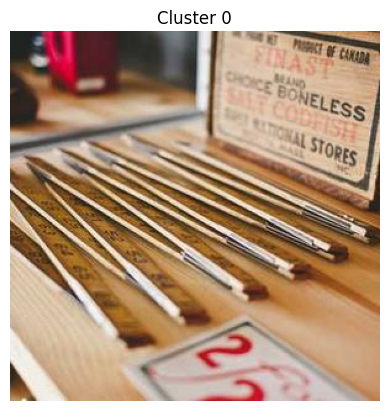

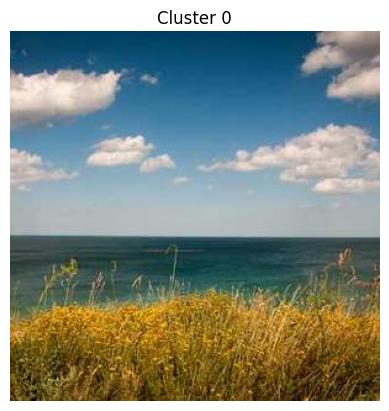


===== Cluster 1 =====


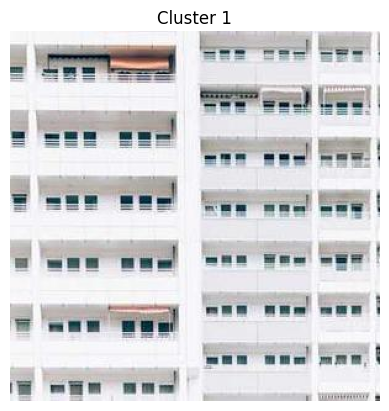

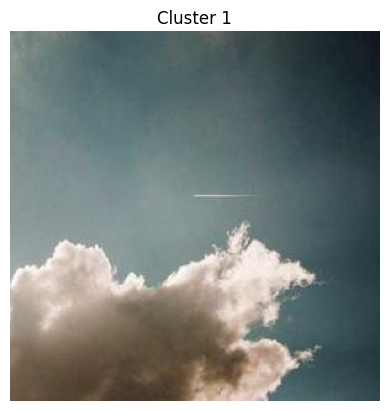

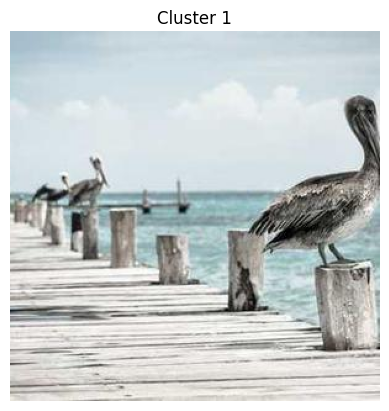


===== Cluster 2 =====


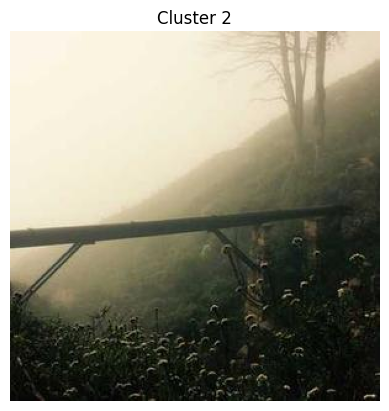

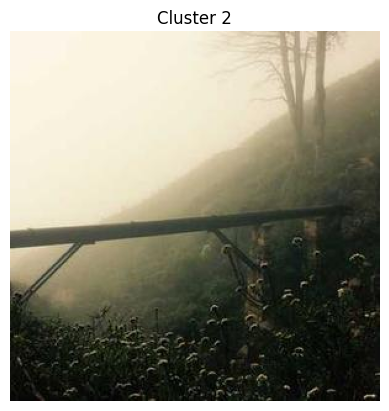

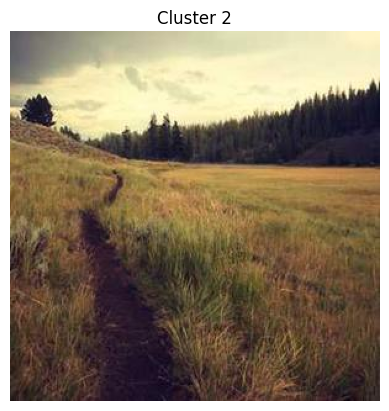

In [ ]:
import cv2
import numpy as np
import requests
from io import BytesIO
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Function: Download image from URL
def load_image_from_url(url):
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        img_array = np.frombuffer(response.content, np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
        if img is None:
            print("Could not decode:", url)
        return img
    except Exception as e:
        print("Error loading", url, ":", e)
        return None

# Function: Compute color histogram
def calculate_color_histogram(image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    hist = cv2.calcHist([image], [0,1,2], None, [8,8,8], [0,256,0,256,0,256])
    hist = cv2.normalize(hist, hist).flatten()
    return hist

# ONLINE IMAGE URL
image_urls = [
    "https://picsum.photos/300/300?random=1",
    "https://picsum.photos/300/300?random=2",
    "https://picsum.photos/300/300?random=3",
    "https://picsum.photos/300/300?random=4", # Corrected typo here
    "https://picsum.photos/300/300?random=5",
    "https://picsum.photos/300/300?random=6",
    "https://picsum.photos/300/300?random=7",
    "https://picsum.photos/300/300?random=8",
    "https://picsum.photos/300/300?random=9",
    "https://picsum.photos/300/300?random=10",
    "https://picsum.photos/300/300?random=11",
]

feature_list = [] # Corrected initialization
loaded_images = [] # Corrected initialization

# Download + Extract features
for url in image_urls:
    print("Downloading:", url)
    img = load_image_from_url(url)
    if img is None:
        continue
    loaded_images.append(img)
    features = calculate_color_histogram(img)
    feature_list.append(features)

# Validation
if len(feature_list) < 2:
    raise ValueError("Not enough images loaded to perform clustering.")

data_matrix = np.array(feature_list)

#K-MEANS Clustering
K = 3
kmeans = KMeans(n_clusters=K, random_state=42) # Removed space
kmeans.fit(data_matrix)
labels = kmeans.labels_
print("\n Clustering Complete!")

# Display images cluster-wise
for cluster_id in range(K):
    print("\n===== Cluster", cluster_id, "=====")
    cluster_indices = [i for i, label in enumerate(labels) if label == cluster_id]
    for i in cluster_indices[:3]: # show first 3 images
        plt.imshow(cv2.cvtColor(loaded_images[i], cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.title(f"Cluster {cluster_id}")
        plt.show()

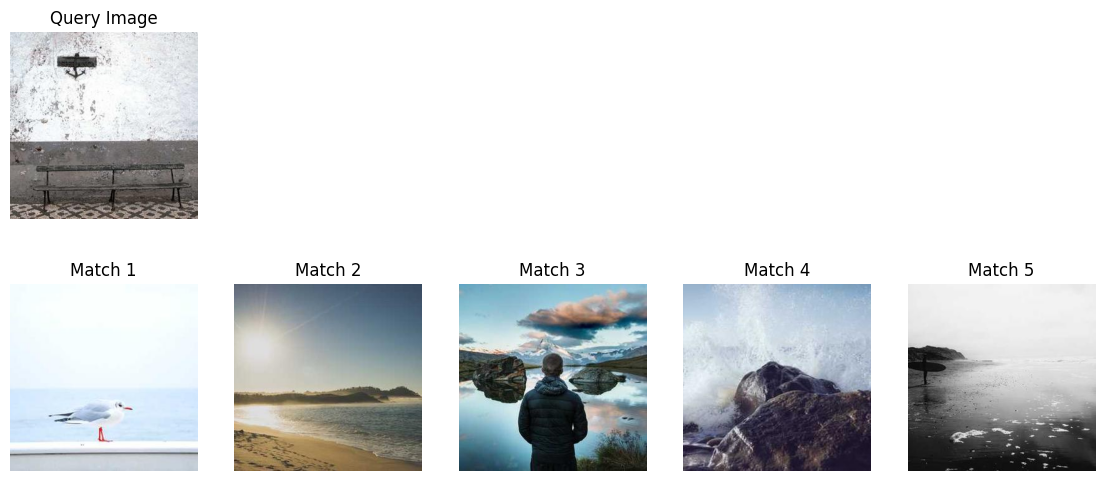

In [ ]:
import os
import cv2
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import urllib.request # Moved import to the top

os.makedirs("images_dataset", exist_ok=True)

# Corrected image_urls definition (list of strings, correct URL format)
image_urls = [
    "https://picsum.photos/300/300?random=1",
    "https://picsum.photos/300/300?random=2",
    "https://picsum.photos/300/300?random=3",
    "https://picsum.photos/300/300?random=4",
    "https://picsum.photos/300/300?random=5"
]

for i, url in enumerate(image_urls):
    save_path = f"images_dataset/img_{i}.jpg"
    urllib.request.urlretrieve(url, save_path)

# Corrected URL for query image
urllib.request.urlretrieve("https://picsum.photos/300/300?random=10", "query.jpg")

def extract_features(image_path):
    img = cv2.imread(image_path, 0)
    orb = cv2.ORB_create(500)
    # Corrected assignment and axis for mean
    keypoints, descriptors = orb.detectAndCompute(img, None)
    if descriptors is None:
        return np.zeros((1, 32))
    return descriptors.mean(axis=0).reshape(1,-1) # Corrected axis

# Corrected list comprehension for image_files
image_files = [f for f in os.listdir("images_dataset") if f.endswith(('.jpg', '.png'))]

features = [] # Stores feature vectors for all dataset images
paths = [] # Stores paths of all images (used later for displaying matches)

for file in image_files:
    img_path = os.path.join("images_dataset", file) # Corrected variable name and module
    f = extract_features(img_path) # Corrected assignment
    features.append(f)
    paths.append(img_path)

features = np.vstack(features)
query_path = "query.jpg"
query_feature = extract_features(query_path) # Corrected assignment

similarity_scores = cosine_similarity(query_feature, features) [0]

# Assuming 'top_k' is a variable to be defined, e.g.
top_k = 5
top_idx = similarity_scores.argsort() [::-1][:top_k]
plt.figure(figsize=(14, 6))
# Display the query image
plt.subplot(2, top_k, 1)
plt.imshow(cv2.cvtColor(cv2.imread(query_path), cv2.COLOR_BGR2RGB))
plt.title("Query Image")
plt.axis("off")
# Display the top-k most similar images
for i, idx in enumerate (top_idx):
    img = cv2.imread(paths [idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, top_k, top_k + i + 1)
    plt.imshow(img)
    plt.title(f"Match {i+1}")
    plt.axis("off") # Added this line to match the query image axis setting
plt.show()

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--2025-12-01 17:52:51--  https://picsum.photos/300/300
Resolving picsum.photos (picsum.photos)... 104.26.4.30, 172.67.74.163, 104.26.5.30, ...
Connecting to picsum.photos (picsum.photos)|104.26.4.30|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://fastly.picsum.photos/id/299/300/300.jpg?hmac=AL30gVrvEQMZgWvQ53mFxMB2rRy8wNO9yDOHwEsO1k0 [following]
--2025-12-01 17:52:51--  https://fastly.picsum.photos/id/299/300/300.jpg?hmac=AL30gVrvEQMZgWvQ53mFxMB2rRy8wNO9yDOHwEsO1k0
Resolving fastly.picsum.photos (fastly.picsum.photos)... 151.101.1.91, 151.101.65.91, 151.101.129.91, ...
Connecting to fastly.picsum.photos (fastly.picsum.photos)|151.101.1.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24923 (24K) [image/jpeg]
Saving to: ‘test_image.jpg’

test_image.jpg      100%[===================>]  24.34K  --.-KB/s    in 0.002s  

2025-12-01 17:52:51 (13.3 MB/s) - ‘test_image.jpg’ sav

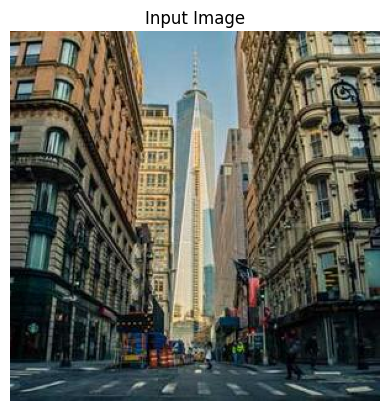

Top Predictions:

palace -> 32.33%
cab -> 17.59%
bell_cote -> 7.40%
dome -> 5.06%
mosque -> 1.97%


In [ ]:
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
model = MobileNetV2(weights='imagenet')

# STEP 3: Download or Upload an Image
# Example image automatically download karte hain
!wget https://picsum.photos/300/300 -O test_image.jpg

# STEP 4: Preprocess the Image (Resize + Normalize)
# Model input size is 224x224 -> resize required
img = image.load_img("test_image.jpg", target_size=(224, 224))

# Image ko numpy array me convert karte hain
img_array = image.img_to_array(img)

# (224,224,3) -> (1,224,224,3) because model expects a batch
img_array = np.expand_dims(img_array, axis=0)

# MobileNetV2 preprocessing -> normalize pixel value
processed_img = preprocess_input(img_array)

# STEP 5: Predict Objects in Image
#
predictions = model.predict(processed_img)

# Convert predictions into human-readable class labels
decoded_results = decode_predictions(predictions, top=5)[0]

# STEP 6: Show the Image & Predictions
#
plt.imshow(image.load_img("test_image.jpg"))
plt.axis("off")
plt.title("Input Image")
plt.show()

print("Top Predictions:\n")
for pred in decoded_results:
    class_name = pred[1]   # Object name
    probability = pred[2]  # Confidence score
    print(f"{class_name} -> {probability*100:.2f}%")


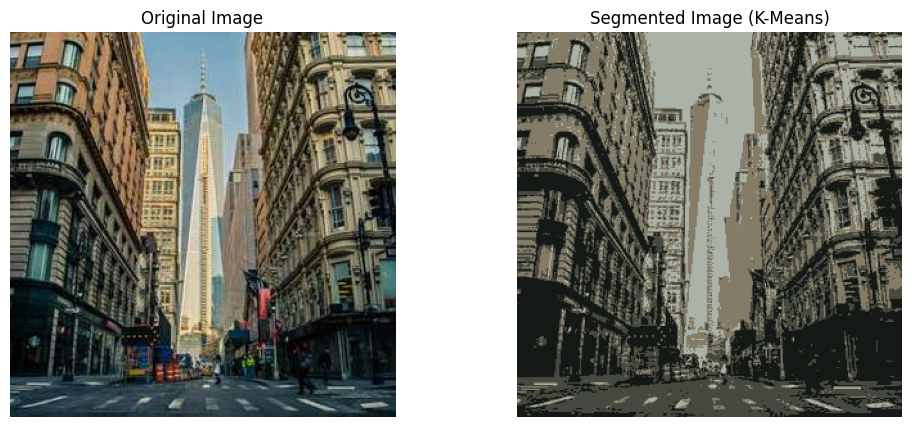

In [ ]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
# Load Image
# Using a valid path for an image previously downloaded in this session
img = cv2.imread("/content/test_image.jpg")

# Check if image was loaded successfully
if img is None:
    print("Error: Could not load the image from the specified path.")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Reshape image for K-Means
    pixel_values = img_rgb.reshape((-1, 3))       # each pixel 3 values (R,G,B)
    pixel_values = np.float32(pixel_values)
    # Apply K-Means Clustering
    K = 4     # number of segments
    kmeans = KMeans(n_clusters=K, random_state=42, n_init=10) # Added n_init to suppress warning
    labels = kmeans.fit_predict(pixel_values)

    # Replace pixel colors with cluster centers
    centers = np.uint8(kmeans.cluster_centers_)
    segmented_data = centers[labels]
    segmented_image = segmented_data.reshape(img_rgb.shape)
    # Show Original vs Segmented
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.title("Original Image")
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.subplot(1,2,2)
    plt.title("Segmented Image (K-Means)")
    plt.imshow(segmented_image)
    plt.axis("off")
    plt.show()